| Model        | Input                | Decomposition |
| ------------ | -------------------- | ------------- |
| Uni-LSTM CI  | CI lags + dummy      | ❌             |
| Uni-LSTM RE  | RE lags + dummy      | ❌             |
| Multi-LSTM   | CI + RE lags + dummy | ❌             |
| BiLSTM CI    | CI lags + dummy      | ❌             |
| BiLSTM RE    | RE lags + dummy      | ❌             |
| BiLSTM Multi | CI + RE lags + dummy | ❌             |


In [1]:
from pathlib import Path
import sys
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

# Project root
project_root = next(
    (
        parent
        for parent in [Path.cwd(), *Path.cwd().parents]
        if (parent / "src").exists()
    ),
    Path.cwd()
)

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.data_loader import TimeSeriesDataLoader
from src.models.deep_learning import LSTMForecaster
from src.evaluation.metrics import ModelEvaluator
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Bidirectional, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

from src.data_loader import TimeSeriesDataLoader

loader = TimeSeriesDataLoader()

In [2]:
feature_path = (
    project_root
    / "data"
    / "processed"
    / "normalized"
    / "dataset_feature_engineered.csv"
)

df = pd.read_csv(feature_path)

df["datetime"] = pd.to_datetime(
    df["datetime"],
    utc=True
)

df = (
    df
    .set_index("datetime")
    .sort_index()
)

print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

Shape: (17496, 84)

Columns:
['carbon_intensity', 'renewable_percentage', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos', 'CI_lag_1', 'CI_lag_3', 'CI_lag_4', 'CI_lag_5', 'CI_lag_6', 'CI_lag_7', 'CI_lag_8', 'CI_lag_9', 'CI_lag_10', 'CI_lag_11', 'CI_lag_12', 'CI_lag_13', 'CI_lag_14', 'CI_lag_15', 'CI_lag_16', 'CI_lag_17', 'CI_lag_18', 'CI_lag_19', 'CI_lag_20', 'CI_lag_21', 'CI_lag_22', 'CI_lag_23', 'CI_lag_24', 'CI_lag_25', 'CI_lag_26', 'CI_lag_27', 'CI_lag_29', 'CI_lag_30', 'CI_lag_31', 'CI_lag_32', 'CI_lag_35', 'CI_lag_36', 'CI_lag_40', 'CI_lag_41', 'CI_lag_44', 'CI_lag_45', 'CI_lag_46', 'CI_lag_47', 'CI_lag_48', 'RE_lag_1', 'RE_lag_2', 'RE_lag_3', 'RE_lag_4', 'RE_lag_5', 'RE_lag_6', 'RE_lag_7', 'RE_lag_10', 'RE_lag_11', 'RE_lag_12', 'RE_lag_13', 'RE_lag_14', 'RE_lag_15', 'RE_lag_17', 'RE_lag_18', 'RE_lag_19', 'RE_lag_20', 'RE_lag_21', 'RE_lag_22', 'RE_lag_23', 'RE_lag_24', 'RE_lag_25', 'RE_lag_26', 'RE_lag_27', 'RE_lag_28', 'RE_lag_31', 'RE_lag_32', 'RE_lag_33'

In [3]:
ci_lag_cols = sorted(
    [
        col for col in df.columns
        if col.startswith("CI_lag_")
    ],
    key=lambda x: int(x.split("_")[-1])
)

re_lag_cols = sorted(
    [
        col for col in df.columns
        if col.startswith("RE_lag_")
    ],
    key=lambda x: int(x.split("_")[-1])
)

print("CI lags:")
print(ci_lag_cols)

print("\nRE lags:")
print(re_lag_cols)

print("\nNumber of CI lags:", len(ci_lag_cols))
print("Number of RE lags:", len(re_lag_cols))

CI lags:
['CI_lag_1', 'CI_lag_3', 'CI_lag_4', 'CI_lag_5', 'CI_lag_6', 'CI_lag_7', 'CI_lag_8', 'CI_lag_9', 'CI_lag_10', 'CI_lag_11', 'CI_lag_12', 'CI_lag_13', 'CI_lag_14', 'CI_lag_15', 'CI_lag_16', 'CI_lag_17', 'CI_lag_18', 'CI_lag_19', 'CI_lag_20', 'CI_lag_21', 'CI_lag_22', 'CI_lag_23', 'CI_lag_24', 'CI_lag_25', 'CI_lag_26', 'CI_lag_27', 'CI_lag_29', 'CI_lag_30', 'CI_lag_31', 'CI_lag_32', 'CI_lag_35', 'CI_lag_36', 'CI_lag_40', 'CI_lag_41', 'CI_lag_44', 'CI_lag_45', 'CI_lag_46', 'CI_lag_47', 'CI_lag_48']

RE lags:
['RE_lag_1', 'RE_lag_2', 'RE_lag_3', 'RE_lag_4', 'RE_lag_5', 'RE_lag_6', 'RE_lag_7', 'RE_lag_10', 'RE_lag_11', 'RE_lag_12', 'RE_lag_13', 'RE_lag_14', 'RE_lag_15', 'RE_lag_17', 'RE_lag_18', 'RE_lag_19', 'RE_lag_20', 'RE_lag_21', 'RE_lag_22', 'RE_lag_23', 'RE_lag_24', 'RE_lag_25', 'RE_lag_26', 'RE_lag_27', 'RE_lag_28', 'RE_lag_31', 'RE_lag_32', 'RE_lag_33', 'RE_lag_34', 'RE_lag_35', 'RE_lag_36', 'RE_lag_39', 'RE_lag_43', 'RE_lag_44', 'RE_lag_45', 'RE_lag_47', 'RE_lag_48']

Numbe

In [4]:
cyclical_cols = [
    "hour_sin",
    "hour_cos",
    "dow_sin",
    "dow_cos",
    "month_sin",
    "month_cos"
]

df_dummy = df.drop(
    columns=cyclical_cols,
    errors="ignore"
).copy()

print("Cyclical features removed.")

print("\nShape:", df_dummy.shape)

Cyclical features removed.

Shape: (17496, 78)


In [5]:
df_dummy = loader.add_seasonal_dummies(
    df_dummy,
    daily=True,
    monthly=True,
    weekly_hour=True,
    drop_first=True
)

print("\nShape after dummy encoding:", df_dummy.shape)

  Seasonal dummies added. Total columns: 279

Shape after dummy encoding: (17496, 279)


In [6]:
dummy_cols = [
    col for col in df_dummy.columns
    if (
        col.startswith("H_")
        or col.startswith("B_")
        or col.startswith("M")
    )
]

print("Number of dummy features:", len(dummy_cols))

print("\nDummy features:")
print(dummy_cols)

Number of dummy features: 201

Dummy features:
['H_2', 'H_3', 'H_4', 'H_5', 'H_6', 'H_7', 'H_8', 'H_9', 'H_10', 'H_11', 'H_12', 'H_13', 'H_14', 'H_15', 'H_16', 'H_17', 'H_18', 'H_19', 'H_20', 'H_21', 'H_22', 'H_23', 'H_24', 'B_2', 'B_3', 'B_4', 'B_5', 'B_6', 'B_7', 'B_8', 'B_9', 'B_10', 'B_11', 'B_12', 'M1H10', 'M1H11', 'M1H12', 'M1H13', 'M1H14', 'M1H15', 'M1H16', 'M1H17', 'M1H18', 'M1H19', 'M1H2', 'M1H20', 'M1H21', 'M1H22', 'M1H23', 'M1H24', 'M1H3', 'M1H4', 'M1H5', 'M1H6', 'M1H7', 'M1H8', 'M1H9', 'M2H1', 'M2H10', 'M2H11', 'M2H12', 'M2H13', 'M2H14', 'M2H15', 'M2H16', 'M2H17', 'M2H18', 'M2H19', 'M2H2', 'M2H20', 'M2H21', 'M2H22', 'M2H23', 'M2H24', 'M2H3', 'M2H4', 'M2H5', 'M2H6', 'M2H7', 'M2H8', 'M2H9', 'M3H1', 'M3H10', 'M3H11', 'M3H12', 'M3H13', 'M3H14', 'M3H15', 'M3H16', 'M3H17', 'M3H18', 'M3H19', 'M3H2', 'M3H20', 'M3H21', 'M3H22', 'M3H23', 'M3H24', 'M3H3', 'M3H4', 'M3H5', 'M3H6', 'M3H7', 'M3H8', 'M3H9', 'M4H1', 'M4H10', 'M4H11', 'M4H12', 'M4H13', 'M4H14', 'M4H15', 'M4H16', 'M4H17', 'M4

In [7]:
CI_COL = "carbon_intensity"
RE_COL = "renewable_percentage"

feature_cols_uni_ci = [
    CI_COL,
    *ci_lag_cols,
    *dummy_cols
]

In [8]:
feature_cols_uni_re = [
    RE_COL,
    *re_lag_cols,
    *dummy_cols
]

In [9]:
feature_cols_multi = [
    CI_COL,
    RE_COL,
    *ci_lag_cols,
    *re_lag_cols,
    *dummy_cols
]

In [10]:
print("=== BASELINE FEATURE CONFIGURATION ===")

print(
    f"\nUnivariate CI "
    f"({len(feature_cols_uni_ci)} features)"
)

print(feature_cols_uni_ci)

print(
    f"\nUnivariate RE "
    f"({len(feature_cols_uni_re)} features)"
)

print(feature_cols_uni_re)

print(
    f"\nMultivariate "
    f"({len(feature_cols_multi)} features)"
)

print(feature_cols_multi)

=== BASELINE FEATURE CONFIGURATION ===

Univariate CI (241 features)
['carbon_intensity', 'CI_lag_1', 'CI_lag_3', 'CI_lag_4', 'CI_lag_5', 'CI_lag_6', 'CI_lag_7', 'CI_lag_8', 'CI_lag_9', 'CI_lag_10', 'CI_lag_11', 'CI_lag_12', 'CI_lag_13', 'CI_lag_14', 'CI_lag_15', 'CI_lag_16', 'CI_lag_17', 'CI_lag_18', 'CI_lag_19', 'CI_lag_20', 'CI_lag_21', 'CI_lag_22', 'CI_lag_23', 'CI_lag_24', 'CI_lag_25', 'CI_lag_26', 'CI_lag_27', 'CI_lag_29', 'CI_lag_30', 'CI_lag_31', 'CI_lag_32', 'CI_lag_35', 'CI_lag_36', 'CI_lag_40', 'CI_lag_41', 'CI_lag_44', 'CI_lag_45', 'CI_lag_46', 'CI_lag_47', 'CI_lag_48', 'H_2', 'H_3', 'H_4', 'H_5', 'H_6', 'H_7', 'H_8', 'H_9', 'H_10', 'H_11', 'H_12', 'H_13', 'H_14', 'H_15', 'H_16', 'H_17', 'H_18', 'H_19', 'H_20', 'H_21', 'H_22', 'H_23', 'H_24', 'B_2', 'B_3', 'B_4', 'B_5', 'B_6', 'B_7', 'B_8', 'B_9', 'B_10', 'B_11', 'B_12', 'M1H10', 'M1H11', 'M1H12', 'M1H13', 'M1H14', 'M1H15', 'M1H16', 'M1H17', 'M1H18', 'M1H19', 'M1H2', 'M1H20', 'M1H21', 'M1H22', 'M1H23', 'M1H24', 'M1H3', 'M1H

In [11]:
df_dummy = df_dummy.dropna(
    subset=[
        *ci_lag_cols,
        *re_lag_cols
    ]
).copy()

print("Shape after removing lag-induced NaN:", df_dummy.shape)

print("\nRemaining missing values:")
print(
    df_dummy[
        [
            CI_COL,
            RE_COL,
            *ci_lag_cols,
            *re_lag_cols
        ]
    ].isna().sum().sum()
)

Shape after removing lag-induced NaN: (17496, 279)

Remaining missing values:
0


In [12]:
baseline_path = (
    project_root
    / "data"
    / "processed"
    / "normalized"
    / "dataset_baseline_dummy.csv"
)

df_dummy.to_csv(baseline_path)

print(f"\nBaseline dataset saved to:")
print(baseline_path)

print("Final shape:", df_dummy.shape)


Baseline dataset saved to:
/Volumes/Livia's Storage/Users/Documents/Telkom_University/Outside_Classes/Research/CarbonIntensityResearch/app/data/processed/normalized/dataset_baseline_dummy.csv
Final shape: (17496, 279)


In [13]:
train_ci_scaled, test_ci_scaled = loader.split_and_scale(
    df=df_dummy,
    feature_cols=feature_cols_uni_ci,
    target_cols=[CI_COL],
    train_ratio=0.8
)
scaler_ci = loader.feature_scaler

Split: Train=13996, Test=3500
Features scaled: 241


In [14]:
train_re_scaled, test_re_scaled = loader.split_and_scale(
    df=df_dummy,
    feature_cols=feature_cols_uni_re,
    target_cols=[RE_COL],
    train_ratio=0.8
)
scaler_re = loader.feature_scaler

Split: Train=13996, Test=3500
Features scaled: 239


In [15]:
train_multi_scaled, test_multi_scaled = loader.split_and_scale(
    df=df_dummy,
    feature_cols=feature_cols_multi,
    target_cols=[CI_COL, RE_COL],
    train_ratio=0.8
)
scaler_multi = loader.feature_scaler

Split: Train=13996, Test=3500
Features scaled: 279


In [16]:
LOOK_BACK = 24

print("=== CREATING ONE-STEP WINDOWS ===")

# ============================================================
# TRAIN WINDOWS
# ============================================================

X_train_ci, y_train_ci = loader.create_sliding_window(
    train_ci_scaled,
    target_cols=[CI_COL],
    look_back=LOOK_BACK,
    forecast_horizon=1
)

X_train_re, y_train_re = loader.create_sliding_window(
    train_re_scaled,
    target_cols=[RE_COL],
    look_back=LOOK_BACK,
    forecast_horizon=1
)

X_train_multi, y_train_multi = loader.create_sliding_window(
    train_multi_scaled,
    target_cols=[CI_COL, RE_COL],
    look_back=LOOK_BACK,
    forecast_horizon=1
)


# ============================================================
# TEST WINDOW HELPER
# ============================================================

def create_test_window(
    train_df,
    test_df,
    target_cols,
    look_back=24,
    forecast_horizon=1
):
    context = pd.concat([
        train_df.iloc[-look_back:],
        test_df
    ])

    return loader.create_sliding_window(
        context,
        target_cols=target_cols,
        look_back=look_back,
        forecast_horizon=forecast_horizon
    )


# ============================================================
# TEST WINDOWS
# ============================================================

X_test_ci, y_test_ci = create_test_window(
    train_ci_scaled,
    test_ci_scaled,
    target_cols=[CI_COL],
    look_back=LOOK_BACK,
    forecast_horizon=1
)

X_test_re, y_test_re = create_test_window(
    train_re_scaled,
    test_re_scaled,
    target_cols=[RE_COL],
    look_back=LOOK_BACK,
    forecast_horizon=1
)

X_test_multi, y_test_multi = create_test_window(
    train_multi_scaled,
    test_multi_scaled,
    target_cols=[CI_COL, RE_COL],
    look_back=LOOK_BACK,
    forecast_horizon=1
)


# ============================================================
# CHECK
# ============================================================

print("\n=== WINDOW SHAPES ===")

print(
    f"CI    : X_train={X_train_ci.shape}, "
    f"y_train={y_train_ci.shape}, "
    f"X_test={X_test_ci.shape}, "
    f"y_test={y_test_ci.shape}"
)

print(
    f"RE    : X_train={X_train_re.shape}, "
    f"y_train={y_train_re.shape}, "
    f"X_test={X_test_re.shape}, "
    f"y_test={y_test_re.shape}"
)

print(
    f"Multi : X_train={X_train_multi.shape}, "
    f"y_train={y_train_multi.shape}, "
    f"X_test={X_test_multi.shape}, "
    f"y_test={y_test_multi.shape}"
)

=== CREATING ONE-STEP WINDOWS ===
  Sliding window: X=(13972, 24, 241), y=(13972,)
  Sliding window: X=(13972, 24, 239), y=(13972,)
  Sliding window: X=(13972, 24, 279), y=(13972, 2)
  Sliding window: X=(3500, 24, 241), y=(3500,)
  Sliding window: X=(3500, 24, 239), y=(3500,)
  Sliding window: X=(3500, 24, 279), y=(3500, 2)

=== WINDOW SHAPES ===
CI    : X_train=(13972, 24, 241), y_train=(13972,), X_test=(3500, 24, 241), y_test=(3500,)
RE    : X_train=(13972, 24, 239), y_train=(13972,), X_test=(3500, 24, 239), y_test=(3500,)
Multi : X_train=(13972, 24, 279), y_train=(13972, 2), X_test=(3500, 24, 279), y_test=(3500, 2)


In [17]:
def build_lstm(input_shape, output_dim=1):
    model = Sequential([
        LSTM(64, input_shape=input_shape),
        Dropout(0.2),
        Dense(output_dim)
    ])

    model.compile(
        optimizer="adam",
        loss="mse",
        metrics=["mae"]
    )

    return model


def build_bilstm(input_shape, output_dim=1):
    model = Sequential([
        Bidirectional(
            LSTM(64),
            input_shape=input_shape
        ),
        Dropout(0.2),
        Dense(output_dim)
    ])

    model.compile(
        optimizer="adam",
        loss="mse",
        metrics=["mae"]
    )

    return model

In [18]:
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

EPOCHS = 50
BATCH_SIZE = 32
VALIDATION_SPLIT = 0.1

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

print("=== TRAINING CONFIGURATION ===")
print(f"Seed: {SEED}")
print(f"Epochs: {EPOCHS}")
print(f"Batch size: {BATCH_SIZE}")
print(f"Validation split: {VALIDATION_SPLIT}")
print("Early stopping patience: 10")


def plot_model_evaluation(
    history,
    y_true,
    y_pred,
    model_name,
    target_name,
    unit="gCO₂eq/kWh",
    plot_hours=500
):
    mae = np.mean(np.abs(y_true - y_pred))
    plot_hours = min(plot_hours, len(y_true))

    fig, axes = plt.subplots(2, 1, figsize=(16, 10))

    # Loss curve
    axes[0].plot(
        history.history['loss'],
        label='Training Loss',
        color='#3498db'
    )
    axes[0].plot(
        history.history['val_loss'],
        label='Validation Loss',
        color='#e74c3c'
    )
    axes[0].set_title(
        f'Training vs Validation Loss — {model_name}',
        fontsize=14,
        fontweight='bold'
    )
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss (MSE)')
    axes[0].legend()
    axes[0].grid(True, linestyle=':')

    # Actual vs Predicted
    axes[1].plot(
        y_true[:plot_hours],
        label=f'Actual {target_name}',
        color='#2c3e50',
        linewidth=1.5
    )
    axes[1].plot(
        y_pred[:plot_hours],
        label=f'Predicted {target_name} (MAE={mae:.2f})',
        color='#e74c3c',
        linewidth=1,
        alpha=0.8
    )
    axes[1].set_title(
        f'Actual vs Predicted — {model_name} ({plot_hours} jam)',
        fontsize=14,
        fontweight='bold'
    )
    axes[1].set_xlabel('Timestep (jam)')
    axes[1].set_ylabel(unit)
    axes[1].legend()
    axes[1].grid(True, linestyle=':')

    plt.tight_layout()
    plt.show()


=== TRAINING CONFIGURATION ===
Seed: 42
Epochs: 50
Batch size: 32
Validation split: 0.1
Early stopping patience: 10


In [19]:
print("=== TRAINING LSTM — UNIVARIATE CI ===")

model_lstm_ci = build_lstm(
    input_shape=(X_train_ci.shape[1], X_train_ci.shape[2]),
    output_dim=1
)

model_lstm_ci.summary()

=== TRAINING LSTM — UNIVARIATE CI ===


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        78,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 78,401 (306.25 KB)

 Trainable params: 78,401 (306.25 KB)

 Non-trainable params: 0 (0.00 B)

In [20]:
history_lstm_ci = model_lstm_ci.fit(
    X_train_ci,
    y_train_ci,
    validation_split=VALIDATION_SPLIT,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stopping],
    shuffle=False,
    verbose=1
)

Epoch 1/50
393/393 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 0.0205 - mae: 0.1120 - val_loss: 0.0055 - val_mae: 0.0594
Epoch 2/50
393/393 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.0080 - mae: 0.0706 - val_loss: 0.0034 - val_mae: 0.0461
Epoch 3/50
393/393 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - loss: 0.0066 - mae: 0.0638 - val_loss: 0.0029 - val_mae: 0.0423
Epoch 4/50
393/393 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 0.0054 - mae: 0.0576 - val_loss: 0.0027 - val_mae: 0.0412
Epoch 5/50
393/393 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 0.0050 - mae: 0.0553 - val_loss: 0.0030 - val_mae: 0.0433
Epoch 6/50
393/393 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 0.0046 - mae: 0.0533 - val_loss: 0.0034 - val_mae: 0.0469
Epoch 7/50
393/393 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 0.0041 - mae: 0.0496 - val_loss: 0.0034 - val_mae: 0.0465
Epoch 8/50
393/393 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 0.0040 - mae: 0.0490 - val_loss: 0.0032 - val_mae: 0.0452
Epoch 9/50
393/393 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/ste

In [21]:
print("=== EVALUATING BASELINE LSTM — CI ===")

y_pred_ci_scaled = model_lstm_ci.predict(
    X_test_ci,
    verbose=1
)

print(f"Prediction shape: {y_pred_ci_scaled.shape}")
print(f"Actual shape    : {y_test_ci.shape}")

=== EVALUATING BASELINE LSTM — CI ===
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
Prediction shape: (3500, 1)
Actual shape    : (3500,)


In [22]:
from sklearn.preprocessing import MinMaxScaler


train_size = int(len(df_dummy) * 0.8)

scaler_ci = MinMaxScaler(feature_range=(0, 1))

scaler_ci.fit(
    df_dummy.iloc[:train_size][feature_cols_uni_ci]
)

print("CI scaler restored.")
print("Number of features:", scaler_ci.n_features_in_)

CI scaler restored.
Number of features: 241


In [23]:
y_pred_ci_scaled = np.asarray(
    y_pred_ci_scaled
).reshape(-1, 1)

y_test_ci_scaled = np.asarray(
    y_test_ci
).reshape(-1, 1)

ci_target_idx = feature_cols_uni_ci.index(CI_COL)

# Prediction
dummy_pred = np.zeros(
    (len(y_pred_ci_scaled), len(feature_cols_uni_ci))
)

dummy_pred[:, ci_target_idx] = y_pred_ci_scaled.ravel()

y_pred_ci = scaler_ci.inverse_transform(
    dummy_pred
)[:, ci_target_idx]


# Actual
dummy_actual = np.zeros(
    (len(y_test_ci_scaled), len(feature_cols_uni_ci))
)

dummy_actual[:, ci_target_idx] = y_test_ci_scaled.ravel()

y_test_ci_actual = scaler_ci.inverse_transform(
    dummy_actual
)[:, ci_target_idx]


print("=== INVERSE TRANSFORM CHECK ===")
print(
    f"Actual min/max    : "
    f"{y_test_ci_actual.min():.2f} / "
    f"{y_test_ci_actual.max():.2f}"
)

print(
    f"Prediction min/max: "
    f"{y_pred_ci.min():.2f} / "
    f"{y_pred_ci.max():.2f}"
)

=== INVERSE TRANSFORM CHECK ===
Actual min/max    : 562.73 / 610.36
Prediction min/max: 561.87 / 613.55


In [24]:
from src.evaluation.metrics import ModelEvaluator

evaluator = ModelEvaluator()

score_ci_lstm = evaluator.calculate_metrics(
    y_true=y_test_ci_actual,
    y_pred=y_pred_ci
)

print("=== BASELINE LSTM — CI RESULTS ===")

for metric, score in score_ci_lstm.items():
    print(f"{metric}: {score:.4f}")

=== BASELINE LSTM — CI RESULTS ===
RMSE: 3.1914
MAE: 2.5556
MAPE (%): 0.4379
MSE: 10.1850


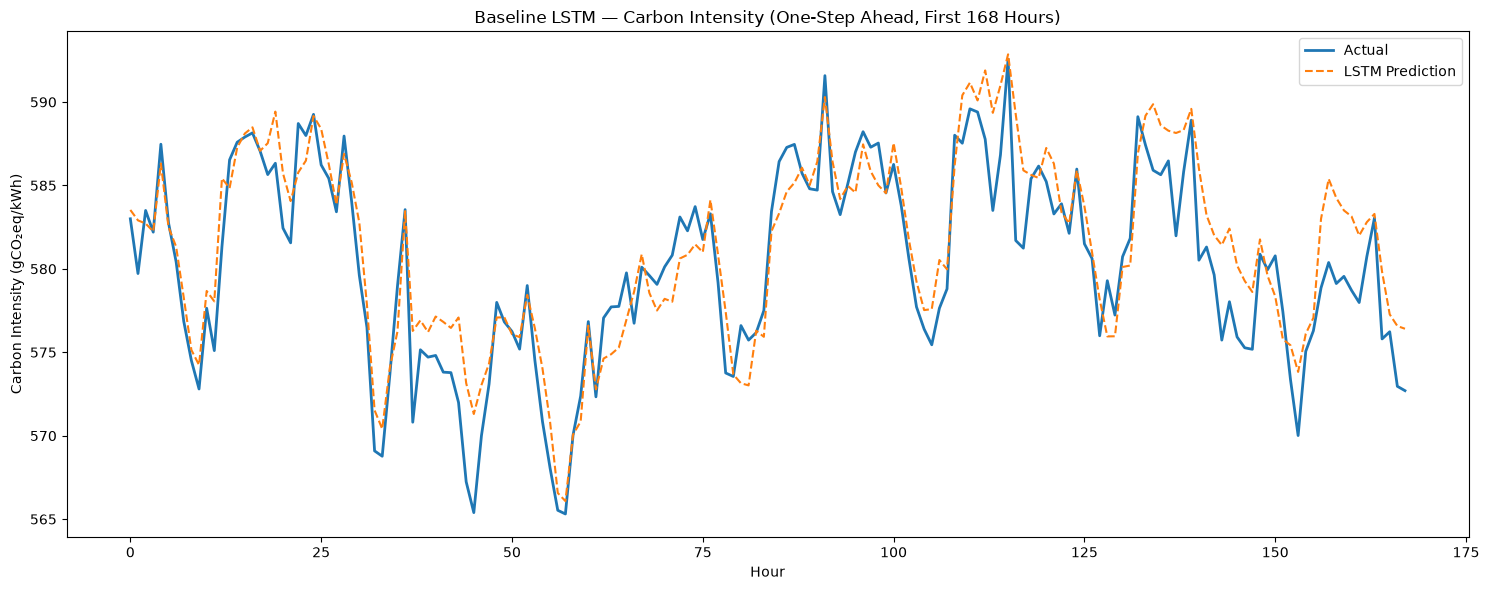

In [25]:
plt.figure(figsize=(15, 6))

plt.plot(
    y_test_ci_actual[:168],
    label="Actual",
    linewidth=2
)

plt.plot(
    y_pred_ci[:168],
    label="LSTM Prediction",
    linestyle="--"
)

plt.title(
    "Baseline LSTM — Carbon Intensity "
    "(One-Step Ahead, First 168 Hours)"
)

plt.xlabel("Hour")
plt.ylabel("Carbon Intensity (gCO₂eq/kWh)")
plt.legend()
plt.tight_layout()
plt.show()

In [26]:
baseline_results = []

baseline_results.append({
    "Model": "LSTM",
    "Target": "Carbon Intensity",
    "Input": "PACF Lags + Seasonal Dummies",
    "Decomposition": "None",
    "Horizon": "One-Step Ahead",
    **score_ci_lstm
})

results_df = pd.DataFrame(baseline_results)

print(results_df.to_string(index=False))

Model           Target                        Input Decomposition        Horizon   RMSE    MAE  MAPE (%)    MSE
 LSTM Carbon Intensity PACF Lags + Seasonal Dummies          None One-Step Ahead 3.1914 2.5556    0.4379 10.185


In [27]:
from sklearn.preprocessing import MinMaxScaler

train_size = int(len(df_dummy) * 0.8)

scaler_re = MinMaxScaler(feature_range=(0, 1))

scaler_re.fit(
    df_dummy.iloc[:train_size][feature_cols_uni_re]
)

print("RE scaler restored.")
print("Number of features:", scaler_re.n_features_in_)

RE scaler restored.
Number of features: 239


In [28]:
print("=== TRAINING LSTM — UNIVARIATE RE ===")

early_stopping_re = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

model_lstm_re = build_lstm(
    input_shape=(
        X_train_re.shape[1],
        X_train_re.shape[2]
    ),
    output_dim=1
)

model_lstm_re.summary()

history_lstm_re = model_lstm_re.fit(
    X_train_re,
    y_train_re,
    validation_split=VALIDATION_SPLIT,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stopping_re],
    shuffle=False,
    verbose=1
)

=== TRAINING LSTM — UNIVARIATE RE ===


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 64)             │        77,824 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 77,889 (304.25 KB)

 Trainable params: 77,889 (304.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
393/393 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 0.0181 - mae: 0.1040 - val_loss: 0.0043 - val_mae: 0.0534
Epoch 2/50
393/393 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.0057 - mae: 0.0597 - val_loss: 0.0032 - val_mae: 0.0448
Epoch 3/50
393/393 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - loss: 0.0047 - mae: 0.0542 - val_loss: 0.0028 - val_mae: 0.0420
Epoch 4/50
393/393 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - loss: 0.0040 - mae: 0.0495 - val_loss: 0.0026 - val_mae: 0.0407
Epoch 5/50
393/393 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 0.0037 - mae: 0.0481 - val_loss: 0.0022 - val_mae: 0.0376
Epoch 6/50
393/393 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.0033 - mae: 0.0451 - val_loss: 0.0021 - val_mae: 0.0361
Epoch 7/50
393/393 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 0.0031 - mae: 0.0436 - val_loss: 0.0021 - val_mae: 0.0362
Epoch 8/50
393/393 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0029 - mae: 0.0425 - val_loss: 0.0019 - val_mae: 0.0346
Epoch 9/50
393/393 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step 

In [29]:
print("=== EVALUATING BASELINE LSTM — RE ===")

y_pred_re_scaled = model_lstm_re.predict(
    X_test_re,
    verbose=1
)

print(f"Prediction shape: {y_pred_re_scaled.shape}")
print(f"Actual shape    : {y_test_re.shape}")

=== EVALUATING BASELINE LSTM — RE ===


110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
Prediction shape: (3500, 1)
Actual shape    : (3500,)


In [30]:
y_pred_re_scaled = np.asarray(
    y_pred_re_scaled
).reshape(-1, 1)

y_test_re_scaled = np.asarray(
    y_test_re
).reshape(-1, 1)

re_target_idx = feature_cols_uni_re.index(RE_COL)

y_pred_re = scaler_re.inverse_transform(
    np.column_stack([
        np.zeros(len(y_pred_re_scaled))
        if i != re_target_idx
        else y_pred_re_scaled.ravel()
        for i in range(len(feature_cols_uni_re))
    ])
)[:, re_target_idx]

y_test_re_original = scaler_re.inverse_transform(
    np.column_stack([
        np.zeros(len(y_test_re_scaled))
        if i != re_target_idx
        else y_test_re_scaled.ravel()
        for i in range(len(feature_cols_uni_re))
    ])
)[:, re_target_idx]

In [31]:
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error
)

rmse_re = np.sqrt(
    mean_squared_error(
        y_test_re_original,
        y_pred_re
    )
)

mae_re = mean_absolute_error(
    y_test_re_original,
    y_pred_re
)

mape_re = np.mean(
    np.abs(
        (y_test_re_original - y_pred_re)
        / np.where(
            y_test_re_original == 0,
            1e-8,
            y_test_re_original
        )
    )
) * 100

mse_re = mean_squared_error(
    y_test_re_original,
    y_pred_re
)

print("=== BASELINE LSTM — RE RESULTS ===")
print(f"RMSE: {rmse_re:.4f}")
print(f"MAE: {mae_re:.4f}")
print(f"MAPE (%): {mape_re:.4f}")
print(f"MSE: {mse_re:.4f}")

=== BASELINE LSTM — RE RESULTS ===
RMSE: 0.2943
MAE: 0.2285
MAPE (%): 1.4249
MSE: 0.0866


In [32]:
print("=== TRAINING LSTM — MULTIVARIATE CI + RE ===")

early_stopping_multi = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

model_lstm_multi = build_lstm(
    input_shape=(
        X_train_multi.shape[1],
        X_train_multi.shape[2]
    ),
    output_dim=2
)

model_lstm_multi.summary()

history_lstm_multi = model_lstm_multi.fit(
    X_train_multi,
    y_train_multi,
    validation_split=VALIDATION_SPLIT,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stopping_multi],
    shuffle=False,
    verbose=1
)

=== TRAINING LSTM — MULTIVARIATE CI + RE ===


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 64)             │        88,064 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 88,194 (344.51 KB)

 Trainable params: 88,194 (344.51 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
393/393 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - loss: 0.0155 - mae: 0.0947 - val_loss: 0.0052 - val_mae: 0.0579
Epoch 2/50
393/393 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.0076 - mae: 0.0692 - val_loss: 0.0120 - val_mae: 0.0919
Epoch 3/50
393/393 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.0061 - mae: 0.0613 - val_loss: 0.0041 - val_mae: 0.0514
Epoch 4/50
393/393 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.0050 - mae: 0.0558 - val_loss: 0.0036 - val_mae: 0.0491
Epoch 5/50
393/393 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 0.0045 - mae: 0.0528 - val_loss: 0.0029 - val_mae: 0.0434
Epoch 6/50
393/393 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.0041 - mae: 0.0503 - val_loss: 0.0028 - val_mae: 0.0428
Epoch 7/50
393/393 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 0.0040 - mae: 0.0495 - val_loss: 0.0027 - val_mae: 0.0416
Epoch 8/50
393/393 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.0037 - mae: 0.0480 - val_loss: 0.0028 - val_mae: 0.0424
Epoch 9/50
393/393 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step -

In [33]:
print("=== EVALUATING BASELINE LSTM — MULTIVARIATE ===")

y_pred_multi_scaled = model_lstm_multi.predict(
    X_test_multi,
    verbose=1
)

print(f"Prediction shape: {y_pred_multi_scaled.shape}")
print(f"Actual shape    : {y_test_multi.shape}")

=== EVALUATING BASELINE LSTM — MULTIVARIATE ===


110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
Prediction shape: (3500, 2)
Actual shape    : (3500, 2)


In [34]:
from sklearn.preprocessing import MinMaxScaler

train_size = int(len(df_dummy) * 0.8)

scaler_multi = MinMaxScaler(feature_range=(0, 1))

scaler_multi.fit(
    df_dummy.iloc[:train_size][feature_cols_multi]
)

print("Multi scaler restored.")
print("Number of features:", scaler_multi.n_features_in_)

Multi scaler restored.
Number of features: 279


In [35]:
def inverse_multivariate_targets(
    y_scaled,
    scaler,
    feature_cols,
    target_cols
):
    y_scaled = np.asarray(y_scaled)

    if y_scaled.ndim == 1:
        y_scaled = y_scaled.reshape(-1, 1)

    dummy = np.zeros(
        (len(y_scaled), len(feature_cols))
    )

    for i, target_col in enumerate(target_cols):
        target_idx = feature_cols.index(target_col)
        dummy[:, target_idx] = y_scaled[:, i]

    inversed = scaler.inverse_transform(dummy)

    target_indices = [
        feature_cols.index(col)
        for col in target_cols
    ]

    return inversed[:, target_indices]

In [36]:
y_pred_multi = inverse_multivariate_targets(
    y_scaled=y_pred_multi_scaled,
    scaler=scaler_multi,
    feature_cols=feature_cols_multi,
    target_cols=[CI_COL, RE_COL]
)

y_test_multi_original = inverse_multivariate_targets(
    y_scaled=y_test_multi,
    scaler=scaler_multi,
    feature_cols=feature_cols_multi,
    target_cols=[CI_COL, RE_COL]
)

print("Prediction shape:", y_pred_multi.shape)
print("Actual shape    :", y_test_multi_original.shape)

Prediction shape: (3500, 2)
Actual shape    : (3500, 2)


In [37]:
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error
)

def calculate_metrics(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)

    denominator = np.where(
        y_true == 0,
        1e-8,
        y_true
    )

    mape = np.mean(
        np.abs(
            (y_true - y_pred) / denominator
        )
    ) * 100

    return {
        "RMSE": rmse,
        "MAE": mae,
        "MAPE (%)": mape,
        "MSE": mse
    }

In [38]:
metrics_multi_ci = calculate_metrics(
    y_test_multi_original[:, 0],
    y_pred_multi[:, 0]
)

metrics_multi_re = calculate_metrics(
    y_test_multi_original[:, 1],
    y_pred_multi[:, 1]
)

print("=== BASELINE LSTM — MULTIVARIATE CI RESULTS ===")

for metric, value in metrics_multi_ci.items():
    print(f"{metric}: {value:.4f}")

print("\n=== BASELINE LSTM — MULTIVARIATE RE RESULTS ===")

for metric, value in metrics_multi_re.items():
    print(f"{metric}: {value:.4f}")

=== BASELINE LSTM — MULTIVARIATE CI RESULTS ===
RMSE: 2.5737
MAE: 2.0420
MAPE (%): 0.3500
MSE: 6.6240

=== BASELINE LSTM — MULTIVARIATE RE RESULTS ===
RMSE: 0.2675
MAE: 0.2062
MAPE (%): 1.3105
MSE: 0.0716


| Model | Target     |       RMSE |    MAE |    MAPE |
| ----- | ---------- | ---------: | -----: | ------: |
| LSTM  | CI         | **3.2445** | 2.5848 | 0.4426% |
| LSTM  | RE         | **0.3490** | 0.2819 | 1.7595% |
| LSTM  | Multi → CI | **2.3674** | 1.8571 | 0.3182% |
| LSTM  | Multi → RE | **0.2777** | 0.2174 | 1.3849% |


In [39]:
print("=== TRAINING BILSTM — UNIVARIATE CI ===")

early_stopping_bilstm_ci = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

model_bilstm_ci = build_bilstm(
    input_shape=(X_train_ci.shape[1], X_train_ci.shape[2]),
    output_dim=1
)

model_bilstm_ci.summary()

history_bilstm_ci = model_bilstm_ci.fit(
    X_train_ci,
    y_train_ci,
    validation_split=VALIDATION_SPLIT,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stopping_bilstm_ci],
    shuffle=False,
    verbose=1
)

=== TRAINING BILSTM — UNIVARIATE CI ===


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)   │ (None, 128)            │       156,672 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 156,801 (612.50 KB)

 Trainable params: 156,801 (612.50 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
393/393 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - loss: 0.0235 - mae: 0.1211 - val_loss: 0.0106 - val_mae: 0.0859
Epoch 2/50
393/393 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - loss: 0.0102 - mae: 0.0803 - val_loss: 0.0154 - val_mae: 0.1041
Epoch 3/50
393/393 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - loss: 0.0071 - mae: 0.0666 - val_loss: 0.0104 - val_mae: 0.0849
Epoch 4/50
393/393 ━━━━━━━━━━━━━━━━━━━━ 8s 21ms/step - loss: 0.0059 - mae: 0.0603 - val_loss: 0.0081 - val_mae: 0.0747
Epoch 5/50
393/393 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - loss: 0.0054 - mae: 0.0578 - val_loss: 0.0091 - val_mae: 0.0794
Epoch 6/50
393/393 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - loss: 0.0047 - mae: 0.0538 - val_loss: 0.0085 - val_mae: 0.0763
Epoch 7/50
393/393 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - loss: 0.0045 - mae: 0.0524 - val_loss: 0.0071 - val_mae: 0.0698
Epoch 8/50
393/393 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - loss: 0.0042 - mae: 0.0506 - val_loss: 0.0087 - val_mae: 0.0777
Epoch 9/50
393/393 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/

In [40]:
print("=== EVALUATING BASELINE BILSTM — CI ===")

y_pred_bilstm_ci_scaled = model_bilstm_ci.predict(
    X_test_ci,
    verbose=1
)

y_pred_bilstm_ci_scaled = np.asarray(
    y_pred_bilstm_ci_scaled
).reshape(-1, 1)

y_test_ci_scaled = np.asarray(
    y_test_ci
).reshape(-1, 1)

print(f"Prediction shape: {y_pred_bilstm_ci_scaled.shape}")
print(f"Actual shape    : {y_test_ci_scaled.shape}")

=== EVALUATING BASELINE BILSTM — CI ===
110/110 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step
Prediction shape: (3500, 1)
Actual shape    : (3500, 1)


In [41]:
y_pred_bilstm_ci = scaler_ci.inverse_transform(
    np.column_stack([
        y_pred_bilstm_ci_scaled.flatten(),
        np.zeros((
            len(y_pred_bilstm_ci_scaled),
            len(feature_cols_uni_ci) - 1
        ))
    ])
)[:, 0]

y_test_ci = scaler_ci.inverse_transform(
    np.column_stack([
        y_test_ci_scaled.flatten(),
        np.zeros((
            len(y_test_ci_scaled),
            len(feature_cols_uni_ci) - 1
        ))
    ])
)[:, 0]

In [42]:
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error
)
import numpy as np

rmse_bilstm_ci = np.sqrt(
    mean_squared_error(y_test_ci, y_pred_bilstm_ci)
)

mae_bilstm_ci = mean_absolute_error(
    y_test_ci,
    y_pred_bilstm_ci
)

mape_bilstm_ci = np.mean(
    np.abs(
        (y_test_ci - y_pred_bilstm_ci)
        / np.where(y_test_ci == 0, 1e-8, y_test_ci)
    )
) * 100

mse_bilstm_ci = mean_squared_error(
    y_test_ci,
    y_pred_bilstm_ci
)

print("=== BASELINE BiLSTM — CI RESULTS ===")
print(f"RMSE: {rmse_bilstm_ci:.4f}")
print(f"MAE: {mae_bilstm_ci:.4f}")
print(f"MAPE (%): {mape_bilstm_ci:.4f}")
print(f"MSE: {mse_bilstm_ci:.4f}")

=== BASELINE BiLSTM — CI RESULTS ===
RMSE: 2.0425
MAE: 1.5743
MAPE (%): 0.2691
MSE: 4.1719


| Model     |       RMSE |        MAE |        MAPE |
| --------- | ---------: | ---------: | ----------: |
| LSTM CI   | **3.2445** | **2.5848** | **0.4426%** |
| BiLSTM CI |     3.8764 |     3.1392 |     0.5382% |


In [43]:
print("=== TRAINING BILSTM — UNIVARIATE RE ===")

early_stopping_bilstm_re = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

model_bilstm_re = build_bilstm(
    input_shape=(
        X_train_re.shape[1],
        X_train_re.shape[2]
    ),
    output_dim=1
)

model_bilstm_re.summary()

history_bilstm_re = model_bilstm_re.fit(
    X_train_re,
    y_train_re,
    validation_split=VALIDATION_SPLIT,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stopping_bilstm_re],
    shuffle=False,
    verbose=1
)

=== TRAINING BILSTM — UNIVARIATE RE ===


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional_1 (Bidirectional) │ (None, 128)            │       155,648 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 155,777 (608.50 KB)

 Trainable params: 155,777 (608.50 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
393/393 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - loss: 0.0190 - mae: 0.1094 - val_loss: 0.0050 - val_mae: 0.0585
Epoch 2/50
393/393 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - loss: 0.0069 - mae: 0.0663 - val_loss: 0.0030 - val_mae: 0.0437
Epoch 3/50
393/393 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - loss: 0.0046 - mae: 0.0539 - val_loss: 0.0025 - val_mae: 0.0400
Epoch 4/50
393/393 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - loss: 0.0044 - mae: 0.0524 - val_loss: 0.0025 - val_mae: 0.0398
Epoch 5/50
393/393 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - loss: 0.0034 - mae: 0.0459 - val_loss: 0.0023 - val_mae: 0.0379
Epoch 6/50
393/393 ━━━━━━━━━━━━━━━━━━━━ 8s 21ms/step - loss: 0.0033 - mae: 0.0454 - val_loss: 0.0022 - val_mae: 0.0375
Epoch 7/50
393/393 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - loss: 0.0033 - mae: 0.0450 - val_loss: 0.0025 - val_mae: 0.0397
Epoch 8/50
393/393 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - loss: 0.0028 - mae: 0.0420 - val_loss: 0.0018 - val_mae: 0.0337
Epoch 9/50
393/393 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/

In [44]:
print("=== EVALUATING BASELINE BILSTM — RE ===")

y_pred_bilstm_re_scaled = model_bilstm_re.predict(
    X_test_re,
    verbose=1
)

y_pred_bilstm_re_scaled = np.asarray(
    y_pred_bilstm_re_scaled
).reshape(-1, 1)

y_test_re_scaled = np.asarray(
    y_test_re
).reshape(-1, 1)

print(f"Prediction shape: {y_pred_bilstm_re_scaled.shape}")
print(f"Actual shape    : {y_test_re_scaled.shape}")

=== EVALUATING BASELINE BILSTM — RE ===
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step
Prediction shape: (3500, 1)
Actual shape    : (3500, 1)


In [45]:
dummy_pred_re = np.zeros(
    (len(y_pred_bilstm_re_scaled), len(feature_cols_uni_re))
)

dummy_test_re = np.zeros(
    (len(y_test_re_scaled), len(feature_cols_uni_re))
)

re_target_idx = feature_cols_uni_re.index(RE_COL)

dummy_pred_re[:, re_target_idx] = (
    y_pred_bilstm_re_scaled.flatten()
)

dummy_test_re[:, re_target_idx] = (
    y_test_re_scaled.flatten()
)

y_pred_bilstm_re = scaler_re.inverse_transform(
    dummy_pred_re
)[:, re_target_idx]

y_test_re_original = scaler_re.inverse_transform(
    dummy_test_re
)[:, re_target_idx]

In [46]:
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error
)
import numpy as np

rmse_bilstm_re = np.sqrt(
    mean_squared_error(
        y_test_re_original,
        y_pred_bilstm_re
    )
)

mae_bilstm_re = mean_absolute_error(
    y_test_re_original,
    y_pred_bilstm_re
)

mape_bilstm_re = np.mean(
    np.abs(
        (y_test_re_original - y_pred_bilstm_re)
        / np.where(
            y_test_re_original == 0,
            1e-8,
            y_test_re_original
        )
    )
) * 100

mse_bilstm_re = mean_squared_error(
    y_test_re_original,
    y_pred_bilstm_re
)

print("=== BASELINE BiLSTM — RE RESULTS ===")
print(f"RMSE: {rmse_bilstm_re:.4f}")
print(f"MAE: {mae_bilstm_re:.4f}")
print(f"MAPE (%): {mape_bilstm_re:.4f}")
print(f"MSE: {mse_bilstm_re:.4f}")

=== BASELINE BiLSTM — RE RESULTS ===
RMSE: 0.3431
MAE: 0.2767
MAPE (%): 1.7334
MSE: 0.1177


| Model         |       RMSE |        MAE |        MAPE |        MSE |
| ------------- | ---------: | ---------: | ----------: | ---------: |
| LSTM RE       |     0.3490 |     0.2819 |     1.7595% |     0.1218 |
| **BiLSTM RE** | **0.3338** | **0.2689** | **1.6763%** | **0.1114** |


In [47]:
print("=== TRAINING BILSTM — MULTIVARIATE ===")

early_stopping_bilstm_multi = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

model_bilstm_multi = build_bilstm(
    input_shape=(
        X_train_multi.shape[1],
        X_train_multi.shape[2]
    ),
    output_dim=2
)

model_bilstm_multi.summary()

history_bilstm_multi = model_bilstm_multi.fit(
    X_train_multi,
    y_train_multi,
    validation_split=VALIDATION_SPLIT,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stopping_bilstm_multi],
    shuffle=False,
    verbose=1
)

=== TRAINING BILSTM — MULTIVARIATE ===


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional_2 (Bidirectional) │ (None, 128)            │       176,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 176,386 (689.01 KB)

 Trainable params: 176,386 (689.01 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
393/393 ━━━━━━━━━━━━━━━━━━━━ 10s 19ms/step - loss: 0.0240 - mae: 0.1148 - val_loss: 0.0054 - val_mae: 0.0582
Epoch 2/50
393/393 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - loss: 0.0075 - mae: 0.0685 - val_loss: 0.0078 - val_mae: 0.0729
Epoch 3/50
393/393 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - loss: 0.0057 - mae: 0.0597 - val_loss: 0.0059 - val_mae: 0.0636
Epoch 4/50
393/393 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - loss: 0.0051 - mae: 0.0566 - val_loss: 0.0053 - val_mae: 0.0600
Epoch 5/50
393/393 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - loss: 0.0047 - mae: 0.0539 - val_loss: 0.0038 - val_mae: 0.0503
Epoch 6/50
393/393 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - loss: 0.0042 - mae: 0.0511 - val_loss: 0.0031 - val_mae: 0.0445
Epoch 7/50
393/393 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - loss: 0.0041 - mae: 0.0502 - val_loss: 0.0030 - val_mae: 0.0433
Epoch 8/50
393/393 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - loss: 0.0040 - mae: 0.0500 - val_loss: 0.0031 - val_mae: 0.0442
Epoch 9/50
393/393 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms

In [48]:
print("=== EVALUATING BASELINE BiLSTM — MULTIVARIATE ===")

y_pred_bilstm_multi_scaled = model_bilstm_multi.predict(
    X_test_multi,
    verbose=1
)

print(f"Prediction shape: {y_pred_bilstm_multi_scaled.shape}")
print(f"Actual shape    : {y_test_multi.shape}")

=== EVALUATING BASELINE BiLSTM — MULTIVARIATE ===
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
Prediction shape: (3500, 2)
Actual shape    : (3500, 2)


In [49]:

target_indices = [
    feature_cols_multi.index(CI_COL),
    feature_cols_multi.index(RE_COL)
]

dummy_pred = np.zeros(
    (y_pred_bilstm_multi_scaled.shape[0], len(feature_cols_multi))
)

dummy_pred[:, target_indices] = y_pred_bilstm_multi_scaled

dummy_pred_inverse = scaler_multi.inverse_transform(dummy_pred)

y_pred_bilstm_multi = dummy_pred_inverse[:, target_indices]


dummy_test = np.zeros(
    (y_test_multi.shape[0], len(feature_cols_multi))
)

dummy_test[:, target_indices] = y_test_multi

dummy_test_inverse = scaler_multi.inverse_transform(dummy_test)

y_test_multi_original = dummy_test_inverse[:, target_indices]

print("Prediction shape:", y_pred_bilstm_multi.shape)
print("Actual shape    :", y_test_multi_original.shape)

print("\nPrediction sample:")
print(y_pred_bilstm_multi[:5])

print("\nActual sample:")
print(y_test_multi_original[:5])

Prediction shape: (3500, 2)
Actual shape    : (3500, 2)

Prediction sample:
[[583.28531466  16.18334195]
 [582.30544279  16.39750209]
 [580.11848424  16.30881316]
 [582.82794581  16.07207234]
 [588.00423759  15.57162078]]

Actual sample:
[[583.    16.39]
 [579.72  16.69]
 [583.5   15.98]
 [582.2   16.15]
 [587.47  15.59]]


In [50]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

# =========================
# CI
# =========================
y_true_ci = y_test_multi_original[:, 0]
y_pred_bilstm_multi_ci = y_pred_bilstm_multi[:, 0]

rmse_ci = np.sqrt(mean_squared_error(y_true_ci, y_pred_bilstm_multi_ci))
mae_ci = mean_absolute_error(y_true_ci, y_pred_bilstm_multi_ci)
mse_ci = mean_squared_error(y_true_ci, y_pred_bilstm_multi_ci)
mape_ci = np.mean(
    np.abs((y_true_ci - y_pred_bilstm_multi_ci) / y_true_ci)
) * 100

print("=== BASELINE BiLSTM — MULTIVARIATE CI RESULTS ===")
print(f"RMSE: {rmse_ci:.4f}")
print(f"MAE: {mae_ci:.4f}")
print(f"MAPE (%): {mape_ci:.4f}")
print(f"MSE: {mse_ci:.4f}")


# =========================
# RE
# =========================
y_true_re = y_test_multi_original[:, 1]
y_pred_bilstm_multi_re = y_pred_bilstm_multi[:, 1]

rmse_re_bilstm_multi = np.sqrt(mean_squared_error(y_true_re, y_pred_bilstm_multi_re))
mae_re_bilstm_multi = mean_absolute_error(y_true_re, y_pred_bilstm_multi_re)
mse_re_bilstm_multi = mean_squared_error(y_true_re, y_pred_bilstm_multi_re)
mape_re_bilstm_multi = np.mean(
    np.abs((y_true_re - y_pred_bilstm_multi_re) / y_true_re)
) * 100

print("\n=== BASELINE BiLSTM — MULTIVARIATE RE RESULTS ===")
print(f"RMSE: {rmse_re_bilstm_multi:.4f}")
print(f"MAE: {mae_re_bilstm_multi:.4f}")
print(f"MAPE (%): {mape_re_bilstm_multi:.4f}")
print(f"MSE: {mse_re_bilstm_multi:.4f}")


=== BASELINE BiLSTM — MULTIVARIATE CI RESULTS ===
RMSE: 2.5585
MAE: 2.0314
MAPE (%): 0.3478
MSE: 6.5461

=== BASELINE BiLSTM — MULTIVARIATE RE RESULTS ===
RMSE: 0.3008
MAE: 0.2323
MAPE (%): 1.4768
MSE: 0.0905


| Model                   |  CI RMSE ↓ |   CI MAE ↓ |  CI MAPE ↓ |  RE RMSE ↓ |   RE MAE ↓ |  RE MAPE ↓ |
| ----------------------- | ---------: | ---------: | ---------: | ---------: | ---------: | ---------: |
| **LSTM Univariate**     |     3.2445 |     2.5848 |     0.4426 |     0.3490 |     0.2819 |     1.7595 |
| **LSTM Multivariate**   | **2.3674** | **1.8571** | **0.3182** | **0.2777** | **0.2174** | **1.3849** |
| **BiLSTM Univariate**   |     3.8764 |     3.1392 |     0.5382 |     0.3338 |     0.2689 |     1.6763 |
| **BiLSTM Multivariate** |     2.4616 |     1.9408 |     0.3322 |     0.2917 |     0.2245 |     1.4334 |


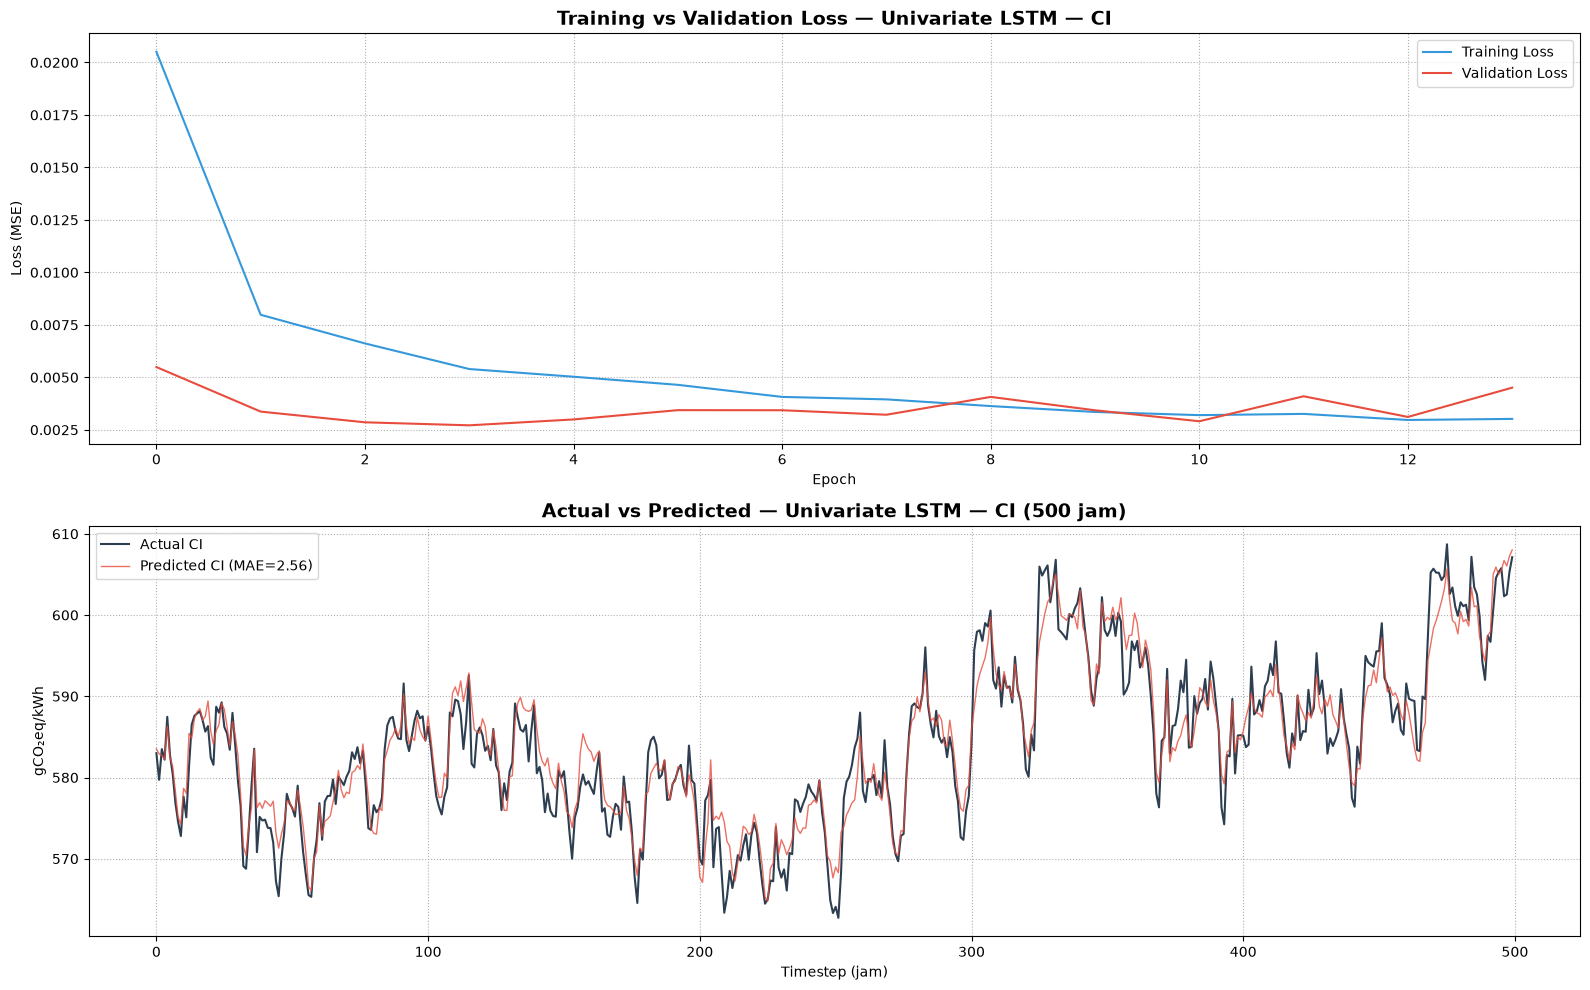

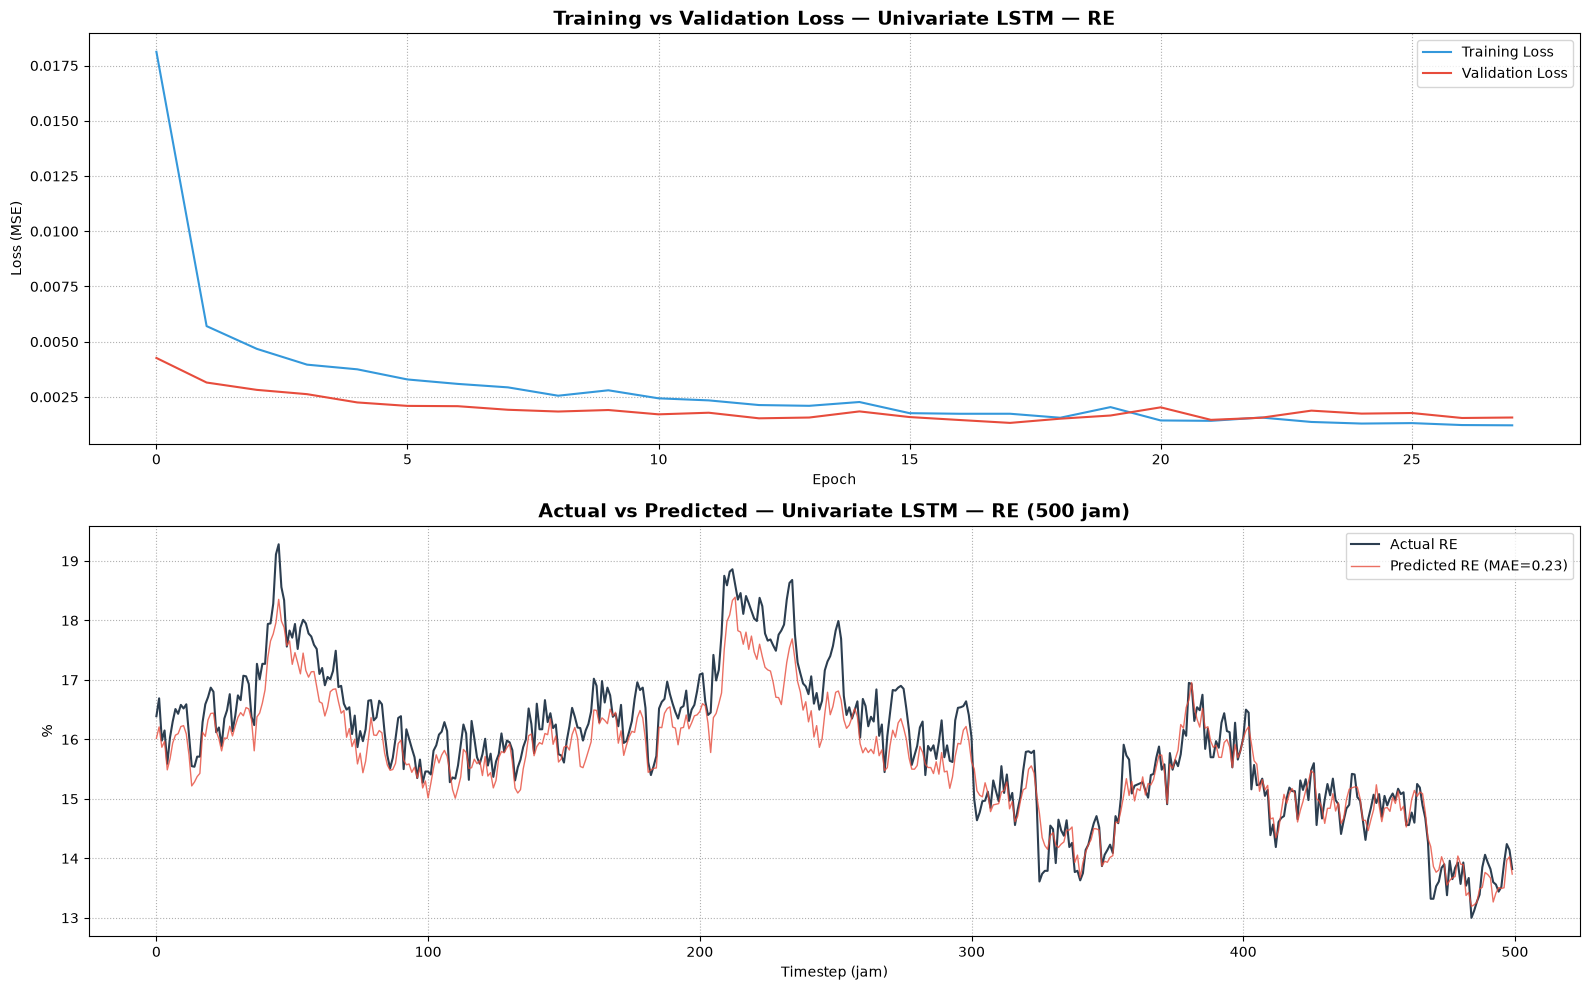

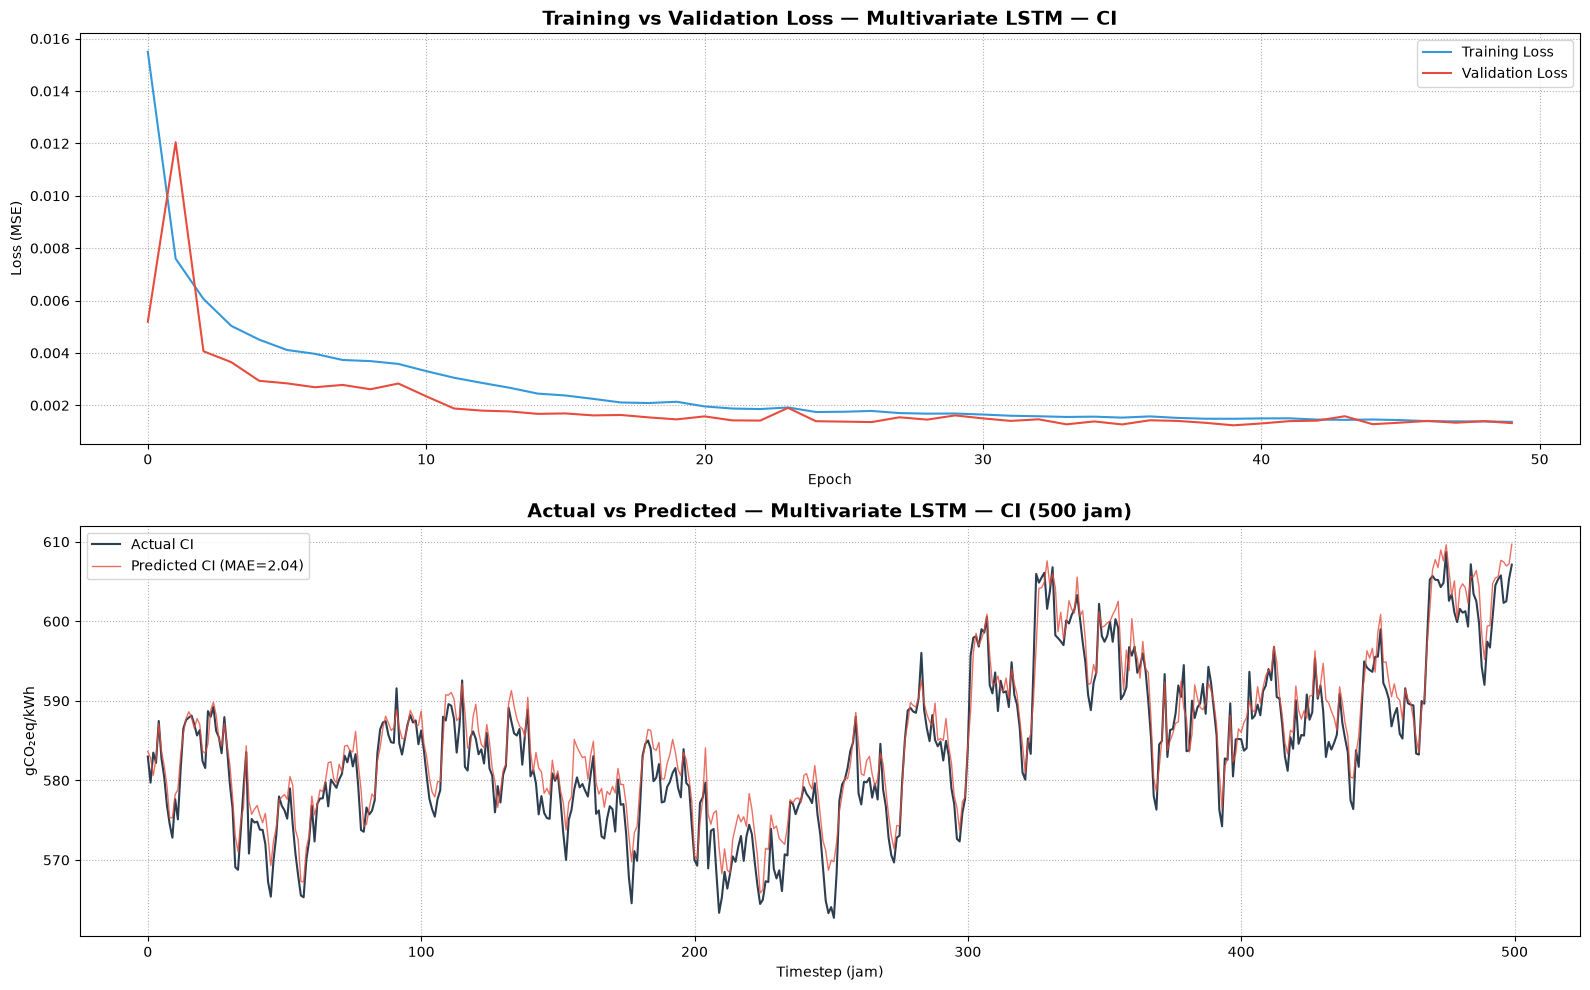

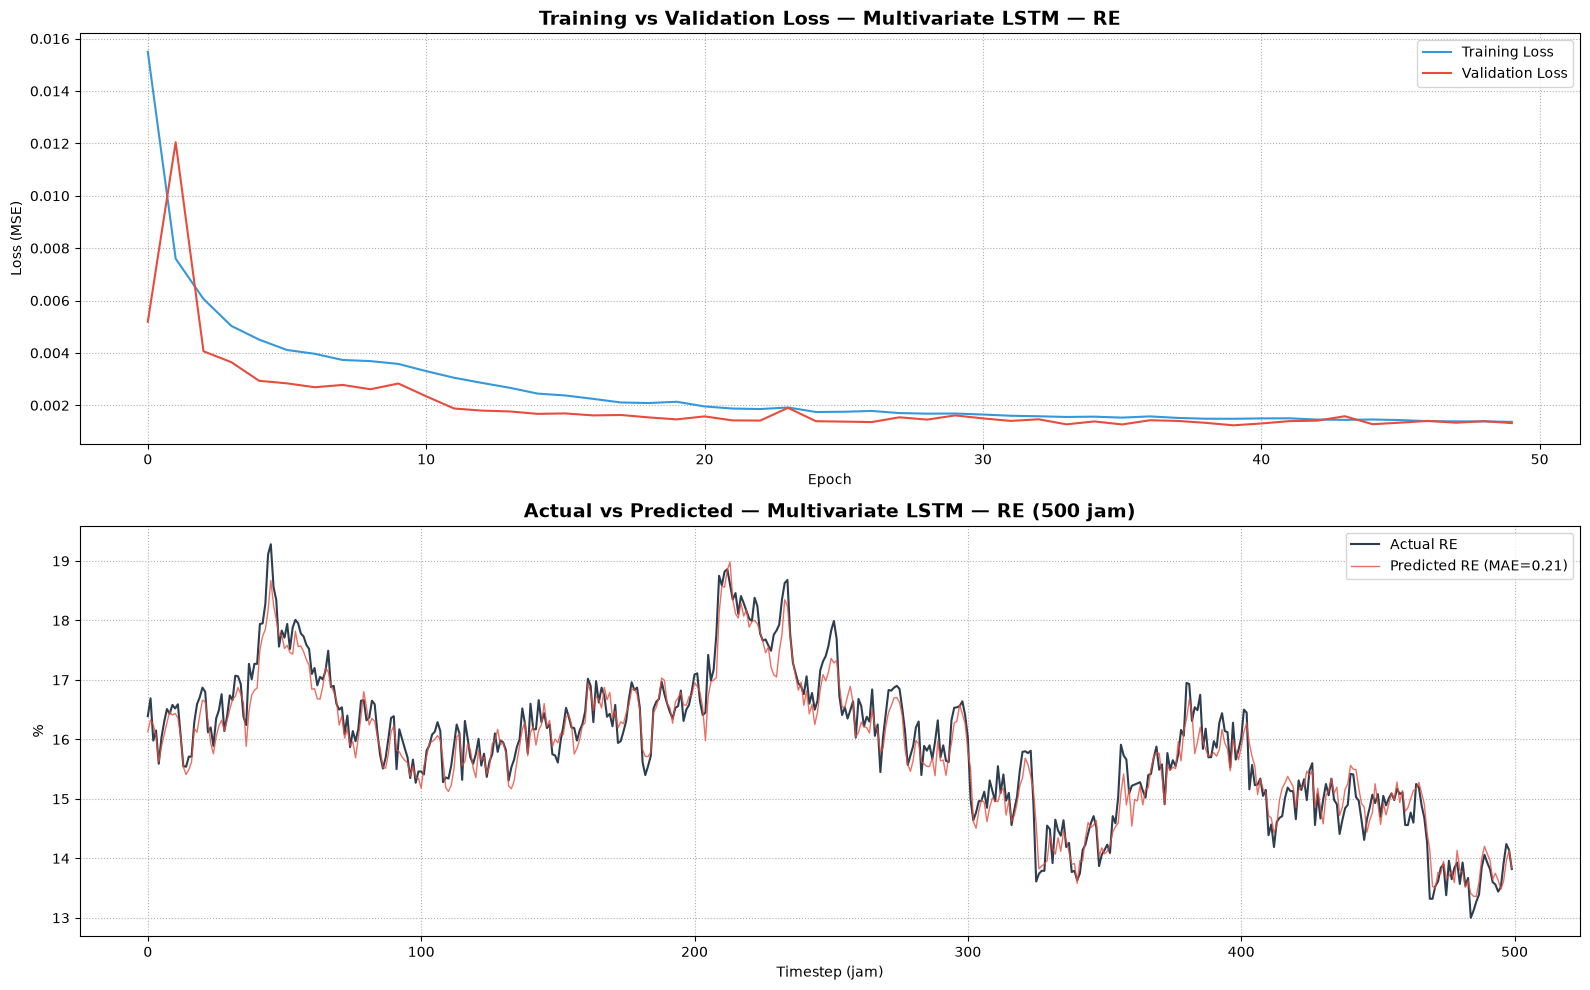

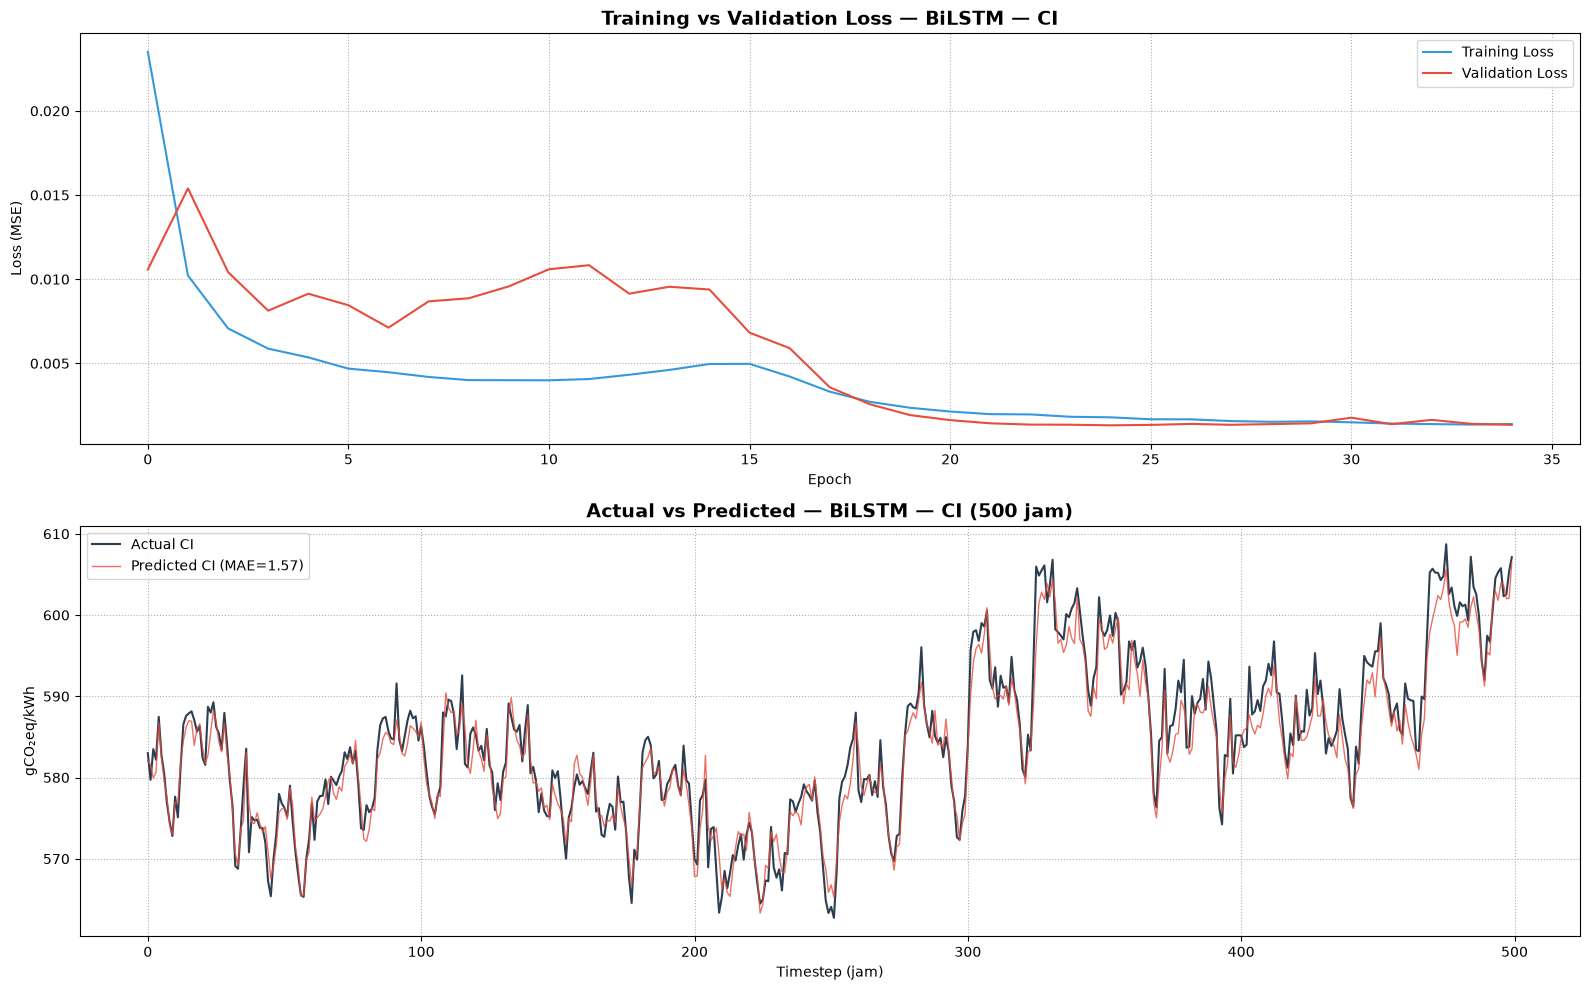

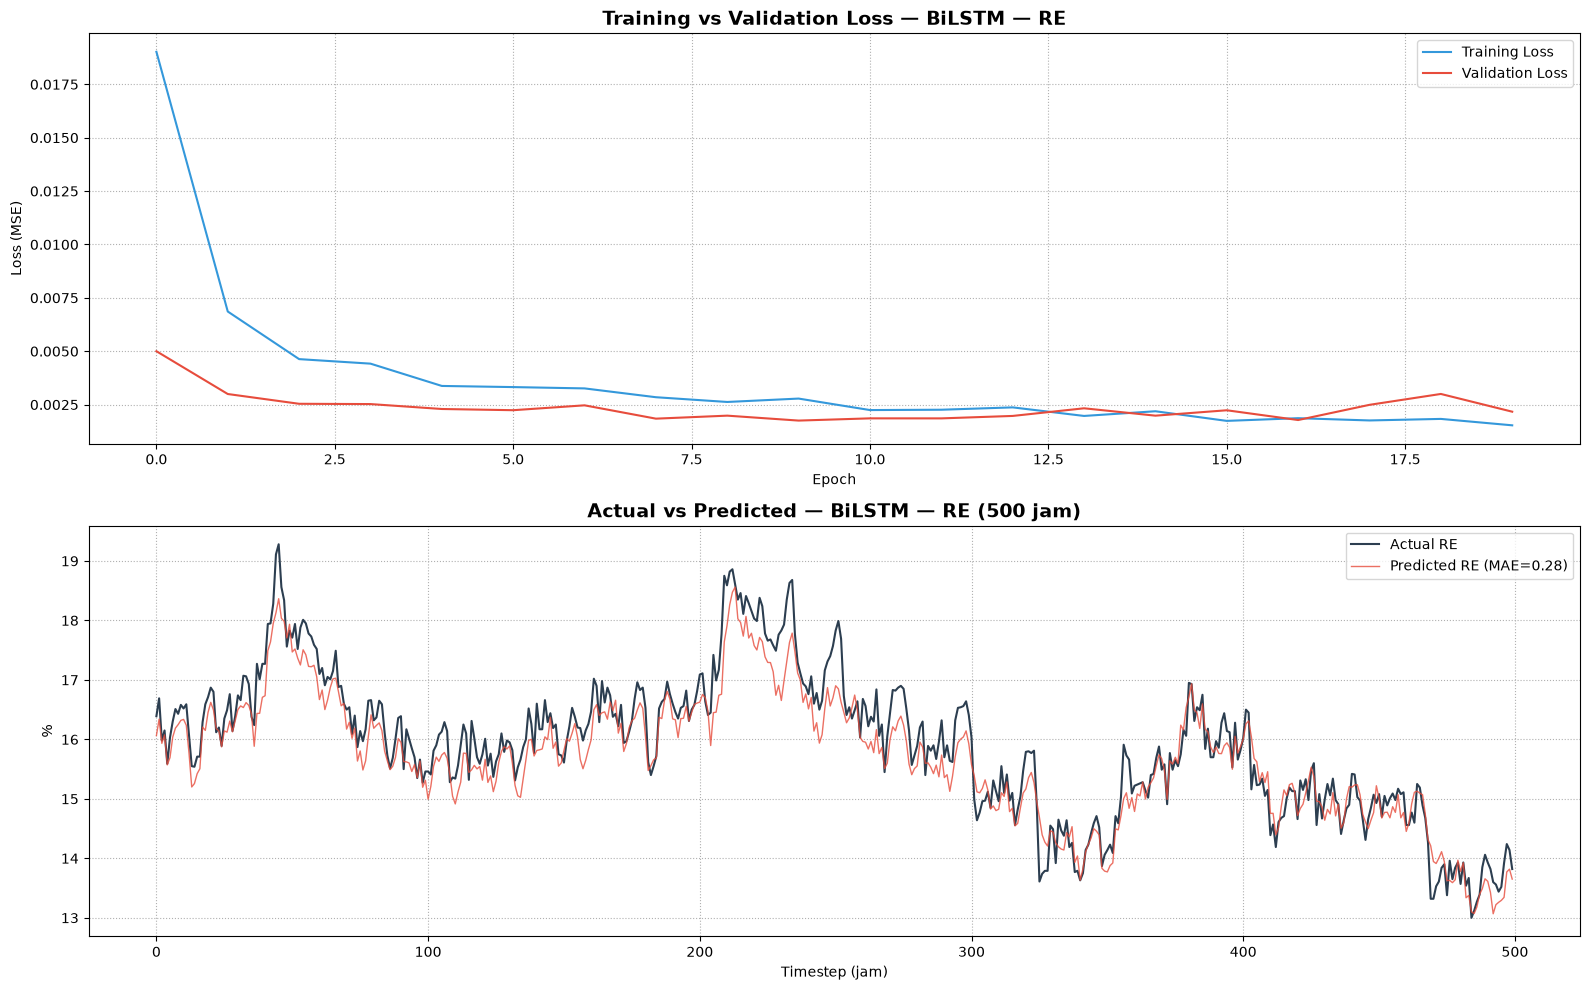

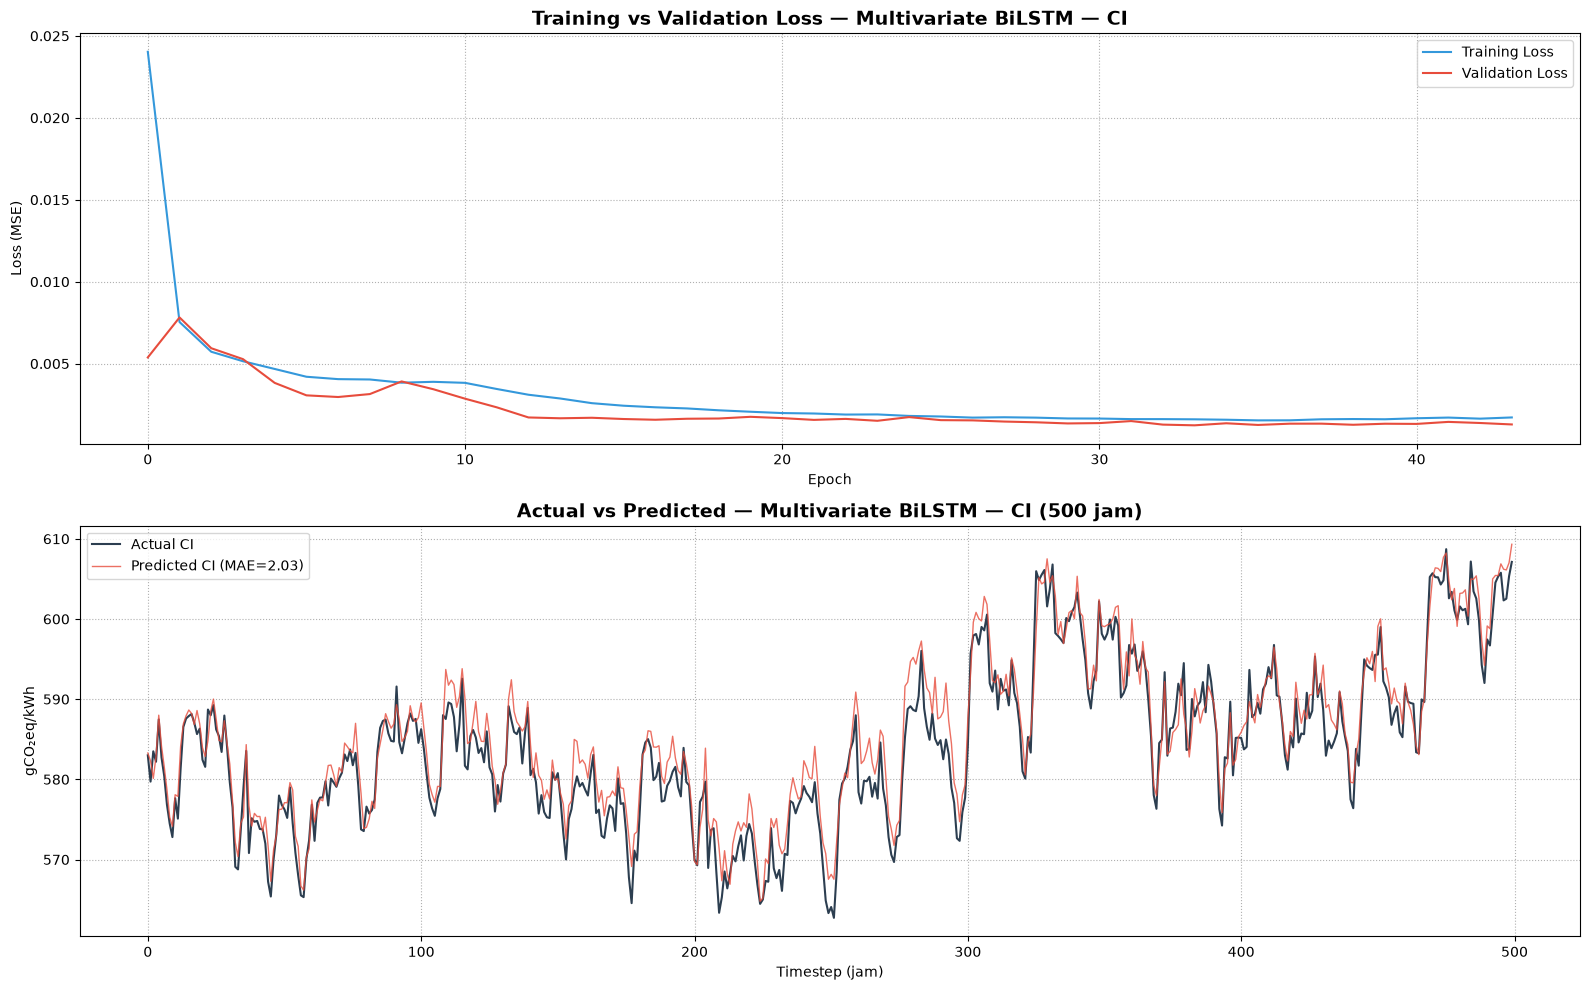

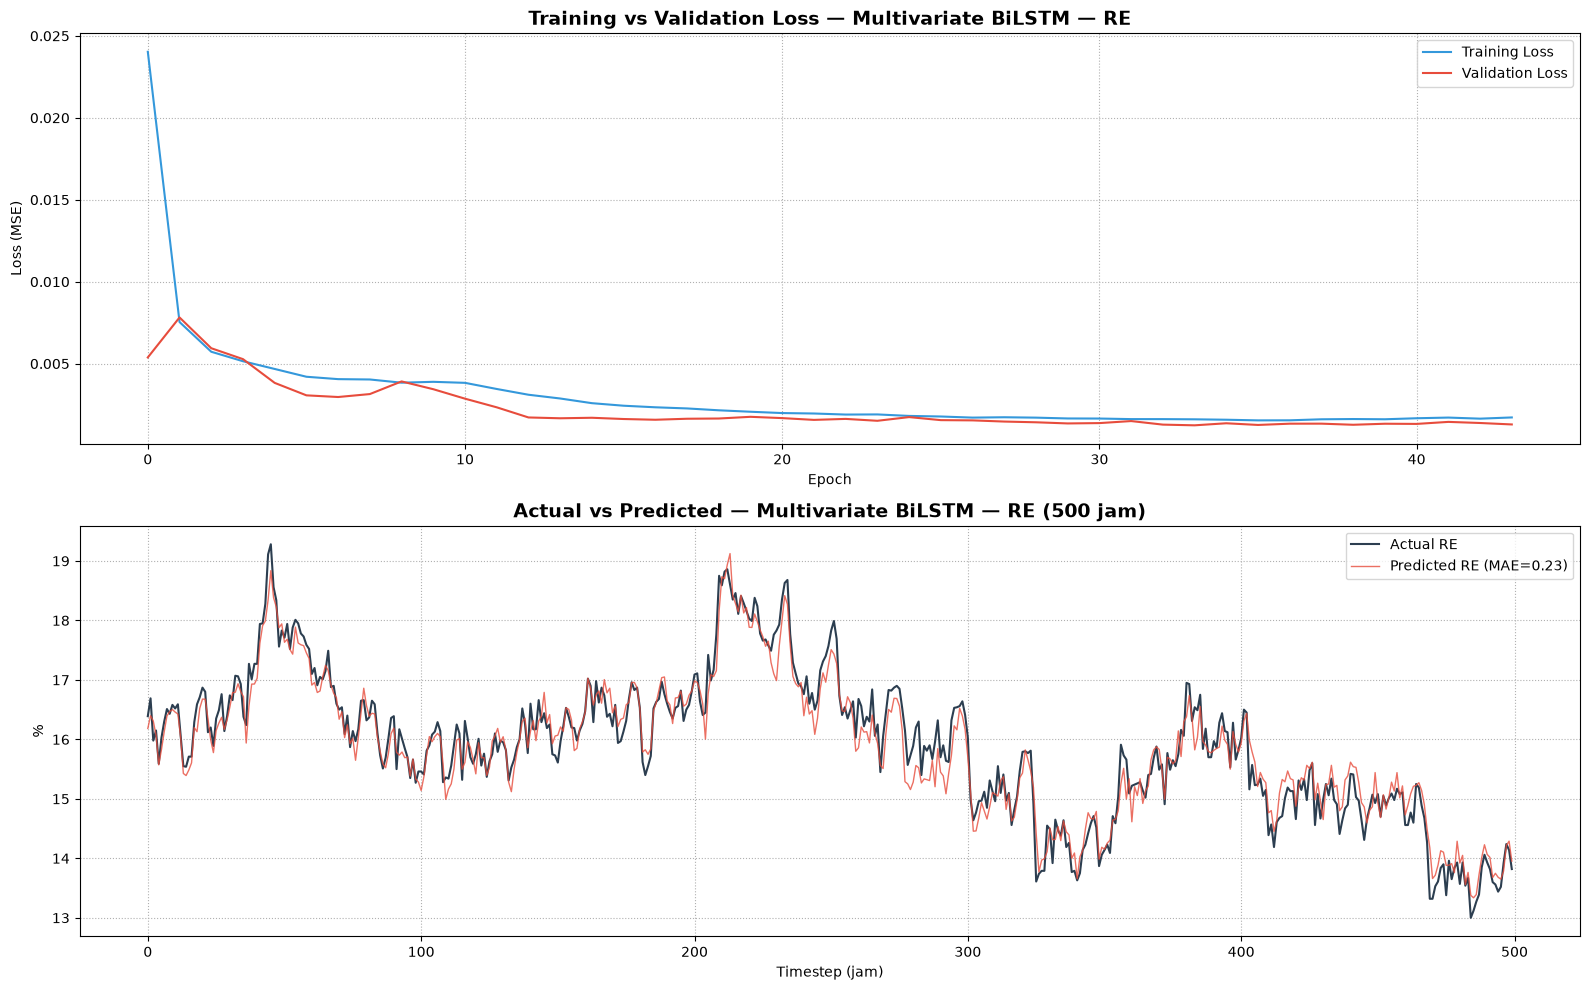

In [51]:
# ============================================================
# MODEL EVALUATION VISUALIZATIONS (Loss & Actual vs Predicted)
# ============================================================

# 1. Univariate LSTM — CI
plot_model_evaluation(
    history=history_lstm_ci,
    y_true=y_test_ci_actual,
    y_pred=y_pred_ci,
    model_name="Univariate LSTM — CI",
    target_name="CI",
    unit="gCO₂eq/kWh"
)

# 2. Univariate LSTM — RE
plot_model_evaluation(
    history=history_lstm_re,
    y_true=y_test_re_original,
    y_pred=y_pred_re,
    model_name="Univariate LSTM — RE",
    target_name="RE",
    unit="%"
)

# 3. Multivariate LSTM — CI
plot_model_evaluation(
    history=history_lstm_multi,
    y_true=y_test_multi_original[:, 0],
    y_pred=y_pred_multi[:, 0],
    model_name="Multivariate LSTM — CI",
    target_name="CI",
    unit="gCO₂eq/kWh"
)

# 4. Multivariate LSTM — RE
plot_model_evaluation(
    history=history_lstm_multi,
    y_true=y_test_multi_original[:, 1],
    y_pred=y_pred_multi[:, 1],
    model_name="Multivariate LSTM — RE",
    target_name="RE",
    unit="%"
)

# 5. BiLSTM — CI
plot_model_evaluation(
    history=history_bilstm_ci,
    y_true=y_test_ci,
    y_pred=y_pred_bilstm_ci,
    model_name="BiLSTM — CI",
    target_name="CI",
    unit="gCO₂eq/kWh"
)

# 6. BiLSTM — RE
plot_model_evaluation(
    history=history_bilstm_re,
    y_true=y_test_re_original,
    y_pred=y_pred_bilstm_re,
    model_name="BiLSTM — RE",
    target_name="RE",
    unit="%"
)

# 7. Multivariate BiLSTM — CI
plot_model_evaluation(
    history=history_bilstm_multi,
    y_true=y_test_multi_original[:, 0],
    y_pred=y_pred_bilstm_multi[:, 0],
    model_name="Multivariate BiLSTM — CI",
    target_name="CI",
    unit="gCO₂eq/kWh"
)

# 8. Multivariate BiLSTM — RE
plot_model_evaluation(
    history=history_bilstm_multi,
    y_true=y_test_multi_original[:, 1],
    y_pred=y_pred_bilstm_multi[:, 1],
    model_name="Multivariate BiLSTM — RE",
    target_name="RE",
    unit="%"
)


In [52]:
# Save evaluation results
results_dir = (
    project_root
    / "results"
    / "deep_learning"
)

results_dir.mkdir(
    parents=True,
    exist_ok=True
)

results = [
    {"Model": "Uni-LSTM CI", "Target": "CI", "RMSE": score_ci_lstm["RMSE"], "MAE": score_ci_lstm["MAE"], "MAPE (%)": score_ci_lstm["MAPE (%)"], "MSE": score_ci_lstm["MSE"]},
    {"Model": "Uni-LSTM RE", "Target": "RE", "RMSE": rmse_re, "MAE": mae_re, "MAPE (%)": mape_re, "MSE": mse_re},
    {"Model": "Multi-LSTM", "Target": "CI", "RMSE": metrics_multi_ci["RMSE"], "MAE": metrics_multi_ci["MAE"], "MAPE (%)": metrics_multi_ci["MAPE (%)"], "MSE": metrics_multi_ci["MSE"]},
    {"Model": "Multi-LSTM", "Target": "RE", "RMSE": metrics_multi_re["RMSE"], "MAE": metrics_multi_re["MAE"], "MAPE (%)": metrics_multi_re["MAPE (%)"], "MSE": metrics_multi_re["MSE"]},
    {"Model": "BiLSTM CI", "Target": "CI", "RMSE": rmse_bilstm_ci, "MAE": mae_bilstm_ci, "MAPE (%)": mape_bilstm_ci, "MSE": mse_bilstm_ci},
    {"Model": "BiLSTM RE", "Target": "RE", "RMSE": rmse_bilstm_re, "MAE": mae_bilstm_re, "MAPE (%)": mape_bilstm_re, "MSE": mse_bilstm_re},
    {"Model": "BiLSTM Multi", "Target": "CI", "RMSE": rmse_ci, "MAE": mae_ci, "MAPE (%)": mape_ci, "MSE": mse_ci},
    {"Model": "BiLSTM Multi", "Target": "RE", "RMSE": rmse_re_bilstm_multi, "MAE": mae_re_bilstm_multi, "MAPE (%)": mape_re_bilstm_multi, "MSE": mse_re_bilstm_multi},
]

results_df = pd.DataFrame(results)

results_path = results_dir / "04_dani_dl_dummy_baseline_metrics.csv"
results_df.to_csv(results_path, index=False)

print("Results saved to:")
print(results_path)
display(results_df)


Results saved to:
/Volumes/Livia's Storage/Users/Documents/Telkom_University/Outside_Classes/Research/CarbonIntensityResearch/app/results/deep_learning/04_dani_dl_dummy_baseline_metrics.csv


,Model,Target,RMSE,MAE,MAPE (%),MSE
0,Uni-LSTM CI,CI,3.191400,2.555600,0.437900,10.185000
1,Uni-LSTM RE,RE,0.294335,0.228466,1.424891,0.086633
2,Multi-LSTM,CI,2.573705,2.041970,0.350006,6.623959
3,Multi-LSTM,RE,0.267492,0.206229,1.310485,0.071552
4,BiLSTM CI,CI,2.042514,1.574316,0.269120,4.171861
5,BiLSTM RE,RE,0.343077,0.276746,1.733444,0.117702
6,BiLSTM Multi,CI,2.558542,2.031410,0.347805,6.546135
7,BiLSTM Multi,RE,0.300823,0.232320,1.476775,0.090494


In [53]:
# Save trained models
models_dir = (
    project_root
    / "models"
    / "deep_learning"
)

models_dir.mkdir(
    parents=True,
    exist_ok=True
)

model_lstm_ci.save(models_dir / "04_lstm_ci_dummy.keras")
model_lstm_re.save(models_dir / "04_lstm_re_dummy.keras")
model_lstm_multi.save(models_dir / "04_lstm_multi_dummy.keras")
model_bilstm_ci.save(models_dir / "04_bilstm_ci_dummy.keras")
model_bilstm_re.save(models_dir / "04_bilstm_re_dummy.keras")
model_bilstm_multi.save(models_dir / "04_bilstm_multi_dummy.keras")

print("All six trained models saved.")


All six trained models saved.
